In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Načtení dat z předzpracování (explran_chr21.ipynb)
matrix_lide = pd.read_pickle('data/matrix_lide.pkl')
matrix_varianty_bool = pd.read_pickle('data/matrix_varianty_bool.pkl')
features_df_clean = pd.read_pickle('data/features_df_clean.pkl')

print(f'matrix_lide: {matrix_lide.shape}')
print(f'matrix_varianty_bool: {matrix_varianty_bool.shape}')
print(f'features_df_clean: {features_df_clean.shape}')

matrix_lide: (2504, 1435)
matrix_varianty_bool: (8550, 13)
features_df_clean: (8550, 3)


### FP_GROWTH


#### Úloha 1 - Soubor asociačních pravidel mezi mutacemi genů 

In [4]:
# === Úloha 1: Asociační pravidla mutace ↔ mutace ===
# Odebrání sloupců s metadaty
matrix_u1 = matrix_lide[[col for col in matrix_lide.columns if not col.startswith(('Sex_', 'Pop_', 'SuperPop_'))]]
print(f"Rozměr matice: {matrix_u1.shape}")

# Filtrování na mutace se support 0.1–0.5 (minor allele frequency)
mutation_support_u1 = matrix_u1.mean()
matrix_keep_u1 = mutation_support_u1[(mutation_support_u1 >= 0.1) & (mutation_support_u1 <= 0.5)].index.tolist()
print(f"Mutací se support 0.1–0.5: {len(matrix_keep_u1)}")

matrix_u1_small = matrix_u1[matrix_keep_u1]
print(f"Finální rozměr: {matrix_u1_small.shape}")

matrix_u1_small.head()

Rozměr matice: (2504, 1401)
Mutací se support 0.1–0.5: 476
Finální rozměr: (2504, 476)


,21_36200305_A_G,21_36201079_C_CT,21_36202482_T_C,21_36205590_T_A-G,21_36208167_G_A,21_36209023_T_A,21_36209650_G_A,21_36215976_G_C,21_36216281_A_G,21_36216883_ATGAG_A,...,21_36491484_A_C,21_36492792_T_C,21_36494739_T_C,21_36496133_A_T,21_36496290_T_TA,21_36496317_C_T,21_36496398_C_T,21_36496838_T_C,21_36497143_A_C,21_36498784_C_T
Sample name,,,,,,,,,,,,,,,,,,,,,
HG00096,False,False,False,False,True,True,False,False,False,False,...,True,True,True,True,True,True,True,True,False,True
HG00097,False,False,False,True,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
HG00099,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,False,True
HG00100,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
HG00101,False,False,False,True,False,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,False


In [5]:
%%time
frequent_itemsets_u1 = fpgrowth(matrix_u1_small, min_support=0.1, use_colnames=True, max_len=2)
print(f"Počet frekventovaných itemsetů: {len(frequent_itemsets_u1)}")

Počet frekventovaných itemsetů: 43876
CPU times: user 2min 41s, sys: 868 ms, total: 2min 42s
Wall time: 2min 43s


In [195]:
%%time
rules_u1 = association_rules(frequent_itemsets_u1, metric="confidence", min_threshold=0.8, num_itemsets=len(frequent_itemsets_u1))
print(f"Počet pravidel: {len(rules_u1)}")
rules_u1.sort_values('lift', ascending=False).head(20)

Počet pravidel: 8261
CPU times: user 1.17 s, sys: 21.3 ms, total: 1.19 s
Wall time: 1.26 s


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8014,frozenset({21_36328928_C_A}),frozenset({21_36328437_G_A}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
8015,frozenset({21_36328018_C_T}),frozenset({21_36328928_C_A}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
8013,frozenset({21_36328437_G_A}),frozenset({21_36328928_C_A}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
8000,frozenset({21_36328437_G_A}),frozenset({21_36328018_C_T}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
7999,frozenset({21_36328018_C_T}),frozenset({21_36328437_G_A}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
8016,frozenset({21_36328928_C_A}),frozenset({21_36328018_C_T}),0.100240,0.100240,0.100240,1.0,9.976096,1.0,0.090192,inf,1.0,1.0,1.0,1.0
7964,frozenset({21_36302887_T_C}),frozenset({21_36301646_T_A}),0.104233,0.104233,0.104233,1.0,9.593870,1.0,0.093369,inf,1.0,1.0,1.0,1.0
7963,frozenset({21_36301646_T_A}),frozenset({21_36302887_T_C}),0.104233,0.104233,0.104233,1.0,9.593870,1.0,0.093369,inf,1.0,1.0,1.0,1.0
7916,frozenset({21_36322739_A_AT}),frozenset({21_36322733_T_TA}),0.104633,0.104633,0.104633,1.0,9.557252,1.0,0.093685,inf,1.0,1.0,1.0,1.0
7917,frozenset({21_36322733_T_TA}),frozenset({21_36322739_A_AT}),0.104633,0.104633,0.104633,1.0,9.557252,1.0,0.093685,inf,1.0,1.0,1.0,1.0


In [196]:
print(f"Celkový počet pravidel: {len(rules_u1)}")
print(f"\nRozložení podle confidence:")
print(f"  Confidence = 1.0: {(rules_u1['confidence'] == 1.0).sum()}")
print(f"  Confidence >= 0.9: {(rules_u1['confidence'] >= 0.9).sum()}")
print(f"  Confidence >= 0.7: {(rules_u1['confidence'] >= 0.7).sum()}")
print(f"\nRozložení podle liftu:")
print(f"  Lift >= 5: {(rules_u1['lift'] >= 5).sum()}")
print(f"  Lift >= 3: {(rules_u1['lift'] >= 3).sum()}")
print(f"  Lift >= 2: {(rules_u1['lift'] >= 2).sum()}")


Celkový počet pravidel: 8261

Rozložení podle confidence:
  Confidence = 1.0: 652
  Confidence >= 0.9: 5590
  Confidence >= 0.7: 8261

Rozložení podle liftu:
  Lift >= 5: 909
  Lift >= 3: 3219
  Lift >= 2: 7492


In [2]:
# Najdeme skupiny mutací, které mají confidence = 1.0 (perfektní LD)
# Filtrujeme jen pravidla s jednou mutací na každé straně (páry),
# aby výpočet vzdálenosti byl korektní
perfect_rules = rules_u1[
    (rules_u1['confidence'] == 1.0) &
    (rules_u1['antecedents'].apply(len) == 1) &
    (rules_u1['consequents'].apply(len) == 1)
].copy()

# Extrahujeme pozice z variant_id
def get_position(variant_id):
    return int(variant_id.split('_')[1])

# Pro každé pravidlo zjistíme vzdálenost mezi mutacemi
perfect_rules['pos_ant'] = perfect_rules['antecedents'].apply(lambda x: get_position(list(x)[0]))
perfect_rules['pos_con'] = perfect_rules['consequents'].apply(lambda x: get_position(list(x)[0]))
perfect_rules['distance_bp'] = abs(perfect_rules['pos_ant'] - perfect_rules['pos_con'])

print("Perfektní LD pravidla (confidence = 1.0, páry 1:1) — vzdálenosti:")
print(f"  Počet: {len(perfect_rules)}")
print(f"  Min vzdálenost: {perfect_rules['distance_bp'].min()} bp")
print(f"  Max vzdálenost: {perfect_rules['distance_bp'].max()} bp")
print(f"  Medián vzdálenosti: {perfect_rules['distance_bp'].median()} bp")

NameError: name 'rules_u1' is not defined

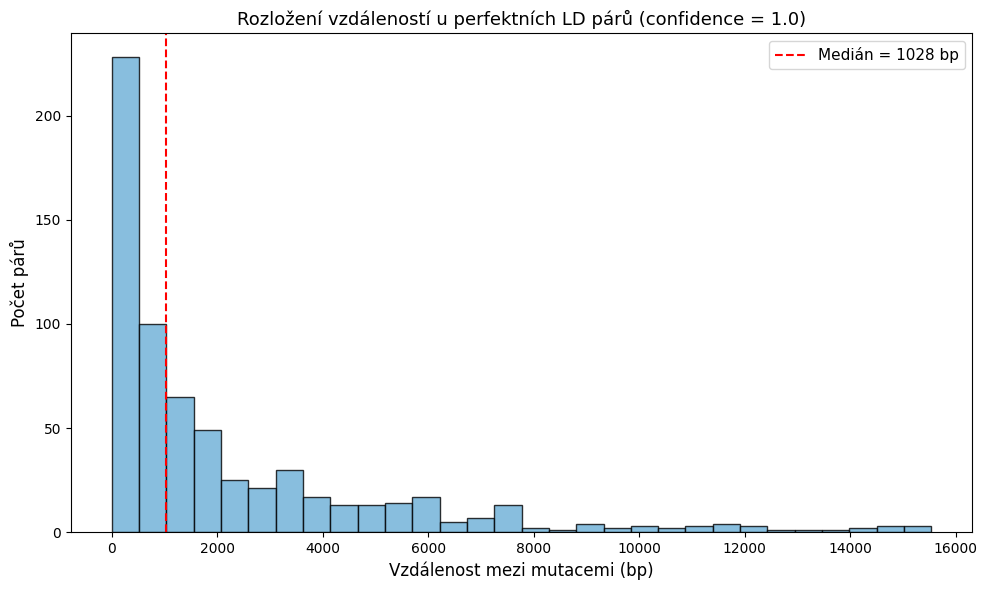

In [198]:
# Histogram vzdáleností u perfektních LD párů (confidence = 1.0)
plt.figure(figsize=(10, 6))
plt.hist(perfect_rules['distance_bp'], bins=30, color='#6baed6', edgecolor='black', alpha=0.8)
plt.xlabel('Vzdálenost mezi mutacemi (bp)', fontsize=12)
plt.ylabel('Počet párů', fontsize=12)
plt.title('Rozložení vzdáleností u perfektních LD párů (confidence = 1.0)', fontsize=13)
plt.axvline(perfect_rules['distance_bp'].median(), color='red', linestyle='--', label=f'Medián = {perfect_rules["distance_bp"].median():.0f} bp')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Pro všechna pravidla 1:1 (páry) zjistíme vzdálenost
rules_u1_pairs = rules_u1[
    (rules_u1['antecedents'].apply(len) == 1) &
    (rules_u1['consequents'].apply(len) == 1)
].copy()

rules_u1_pairs['pos_ant'] = rules_u1_pairs['antecedents'].apply(lambda x: get_position(list(x)[0]))
rules_u1_pairs['pos_con'] = rules_u1_pairs['consequents'].apply(lambda x: get_position(list(x)[0]))
rules_u1_pairs['distance_bp'] = abs(rules_u1_pairs['pos_ant'] - rules_u1_pairs['pos_con'])

plt.figure(figsize=(10, 6))
plt.scatter(rules_u1_pairs['distance_bp'], rules_u1_pairs['lift'], alpha=0.3, s=10, color='#6baed6')

# Zvýraznění zóny lift >= 5 a vzdálenost < 5000 bp
plt.axhline(y=5, color='red', linestyle='--', linewidth=1, alpha=0.8, label='Lift = 5')
plt.axvline(x=5000, color='grey', linestyle='--', linewidth=1, alpha=0.8, label='5 000 bp')
plt.fill_between([0, 5000], 5, rules_u1_pairs['lift'].max() + 0.5,
                 color='red', alpha=0.07)

plt.xlabel('Vzdálenost mezi mutacemi (bp)', fontsize=12)
plt.ylabel('Lift', fontsize=12)
plt.title('Vztah vzdálenosti mutací a síly asociace (lift)', fontsize=13)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Heatmapa párových liftů seřazená podle genomické pozice
# Používáme pravidla 1:1 s lift >= 3 pro lepší pokrytí
strong_pairs = rules_u1_pairs[rules_u1_pairs['lift'] >= 3].copy()

# Extrahujeme unikátní mutace a seřadíme podle pozice
def get_pos(variant_id):
    return int(variant_id.split('_')[1])

all_variants = set()
for _, row in strong_pairs.iterrows():
    all_variants.add(list(row['antecedents'])[0])
    all_variants.add(list(row['consequents'])[0])

variants_sorted = sorted(all_variants, key=get_pos)
var_to_idx = {v: i for i, v in enumerate(variants_sorted)}
n = len(variants_sorted)

# Matice liftů
lift_matrix = np.zeros((n, n))
for _, row in strong_pairs.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    i, j = var_to_idx[ant], var_to_idx[con]
    lift_matrix[i, j] = max(lift_matrix[i, j], row['lift'])
    lift_matrix[j, i] = max(lift_matrix[j, i], row['lift'])

# Popisky — jen pozice
labels = [v.split('_')[1] for v in variants_sorted]

print(f"Mutací v heatmapě: {n}")
print(f"Párů s lift >= 3: {len(strong_pairs) // 2}")

fig, ax = plt.subplots(figsize=(14, 12))
# Maskujeme nuly pro přehlednost
masked = np.ma.masked_where(lift_matrix == 0, lift_matrix)
im = ax.imshow(masked, cmap='YlOrRd', interpolation='nearest', aspect='equal')

# Popisky os — každý N-tý pro čitelnost
step = max(1, n // 25)
tick_positions = list(range(0, n, step))
ax.set_xticks(tick_positions)
ax.set_xticklabels([labels[i] for i in tick_positions], rotation=90, fontsize=7)
ax.set_yticks(tick_positions)
ax.set_yticklabels([labels[i] for i in tick_positions], fontsize=7)

plt.colorbar(im, label='Lift', shrink=0.8)
ax.set_xlabel('Genomická pozice', fontsize=12)
ax.set_ylabel('Genomická pozice', fontsize=12)
ax.set_title('Párové asociace mutací seřazené podle genomické pozice (lift ≥ 3)', fontsize=13)
plt.tight_layout()
plt.show()

In [201]:
rules_u1.sort_values('lift', ascending=False).to_csv('rules_u1_all.csv', index=False)
print(f"Uloženo {len(rules_u1)} pravidel do rules_u1_all.csv")


Uloženo 8261 pravidel do rules_u1_all.csv


#### Úloha 2 – Soubor asociačních pravidel mezi mutacemi a predikovaným dopadem
Pravidla ukazující, které geny mají častěji deleteriézní mutace podle predikčních skóre, opět s interpretací výsledků.

In [236]:
%%time
frequent_itemsets_u2 = fpgrowth(matrix_varianty_bool, min_support=0.05, use_colnames=True, max_len=3)
print(f"Počet frekventovaných itemsetů: {len(frequent_itemsets_u2)}")
frequent_itemsets_u2.sort_values('support', ascending=False).head(20)

Počet frekventovaných itemsetů: 33
CPU times: user 27.6 ms, sys: 1.77 ms, total: 29.4 ms
Wall time: 28.5 ms


,support,itemsets
0,0.905965,frozenset({Impact_Benign})
1,0.674503,frozenset({MAF_category_Ultra-rare (<0.001)})
11,0.605380,"frozenset({MAF_category_Ultra-rare (<0.001), I..."
4,0.408421,frozenset({DOMINANT_POP_AFR})
18,0.372281,"frozenset({Impact_Benign, DOMINANT_POP_AFR})"
19,0.214269,"frozenset({MAF_category_Ultra-rare (<0.001), D..."
3,0.197076,frozenset({DOMINANT_POP_EAS})
20,0.191228,"frozenset({MAF_category_Ultra-rare (<0.001), I..."
5,0.180585,frozenset({MAF_category_Rare (0.001-0.01)})
15,0.178713,"frozenset({Impact_Benign, DOMINANT_POP_EAS})"


In [237]:
%%time
rules_u2 = association_rules(frequent_itemsets_u2, metric="confidence", min_threshold=0.7, num_itemsets=len(frequent_itemsets_u2))
print(f"Počet pravidel: {len(rules_u2)}")
rules_u2.sort_values('lift', ascending=False).head(20)

Počet pravidel: 27
CPU times: user 5.87 ms, sys: 487 μs, total: 6.36 ms
Wall time: 6.03 ms


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,frozenset({DOMINANT_POP_AMR}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.097661,0.605380,0.072865,0.746108,1.232462,1.0,0.013744,1.554281,0.209030,0.115627,0.356616,0.433235
22,frozenset({DOMINANT_POP_AMR}),frozenset({MAF_category_Ultra-rare (<0.001)}),0.097661,0.674503,0.080000,0.819162,1.214467,1.0,0.014127,1.799934,0.195707,0.115580,0.444424,0.468884
24,"frozenset({Impact_Benign, DOMINANT_POP_AMR})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.089006,0.674503,0.072865,0.818660,1.213723,1.0,0.012831,1.794951,0.193293,0.105504,0.442882,0.463344
10,frozenset({DOMINANT_POP_EAS}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.197076,0.605380,0.139766,0.709199,1.171493,1.0,0.020460,1.357009,0.182320,0.210907,0.263085,0.470036
2,frozenset({DOMINANT_POP_SAS}),frozenset({MAF_category_Ultra-rare (<0.001)}),0.158246,0.674503,0.124561,0.787140,1.166992,1.0,0.017824,1.529158,0.169998,0.175888,0.346045,0.485906
7,frozenset({DOMINANT_POP_EAS}),frozenset({MAF_category_Ultra-rare (<0.001)}),0.197076,0.674503,0.154737,0.785163,1.164062,1.0,0.021808,1.515090,0.175532,0.215859,0.339973,0.507286
5,frozenset({DOMINANT_POP_SAS}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.158246,0.605380,0.111345,0.703622,1.162281,1.0,0.015546,1.331473,0.165871,0.170701,0.248952,0.443774
4,"frozenset({Impact_Benign, DOMINANT_POP_SAS})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.142222,0.674503,0.111345,0.782895,1.160699,1.0,0.015416,1.499259,0.161405,0.157851,0.333004,0.473986
9,"frozenset({Impact_Benign, DOMINANT_POP_EAS})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.178713,0.674503,0.139766,0.782068,1.159473,1.0,0.019223,1.493572,0.167468,0.195902,0.330464,0.494641
26,frozenset({Impact_Possibly_damaging}),frozenset({MAF_category_Ultra-rare (<0.001)}),0.088070,0.674503,0.064561,0.733068,1.086827,1.0,0.005158,1.219399,0.087605,0.092493,0.179924,0.414392


In [238]:
print(f"Celkový počet pravidel: {len(rules_u2)}")
print(f"\nRozložení podle liftu:")
print(f"  Lift >= 1.4: {(rules_u2['lift'] >= 1.4).sum()}")
print(f"  Lift >= 1.2: {(rules_u2['lift'] >= 1.2).sum()}")
print(f"  Lift >= 1.1: {(rules_u2['lift'] >= 1.1).sum()}")


Celkový počet pravidel: 27

Rozložení podle liftu:
  Lift >= 1.4: 0
  Lift >= 1.2: 3
  Lift >= 1.1: 9


In [239]:
# Pravidla kde figuruje Impact (to je jádro úlohy 2)
rules_u2_impact = rules_u2[
    rules_u2.apply(lambda r:
        any('Impact' in x for x in r['antecedents']) or 
        any('Impact' in x for x in r['consequents'])
    , axis=1)
]
print(f"\nPravidla obsahující Impact: {len(rules_u2_impact)}")
rules_u2_impact.sort_values('lift', ascending=False).head(20)



Pravidla obsahující Impact: 23


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,frozenset({DOMINANT_POP_AMR}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.097661,0.605380,0.072865,0.746108,1.232462,1.0,0.013744,1.554281,0.209030,0.115627,0.356616,0.433235
24,"frozenset({Impact_Benign, DOMINANT_POP_AMR})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.089006,0.674503,0.072865,0.818660,1.213723,1.0,0.012831,1.794951,0.193293,0.105504,0.442882,0.463344
10,frozenset({DOMINANT_POP_EAS}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.197076,0.605380,0.139766,0.709199,1.171493,1.0,0.020460,1.357009,0.182320,0.210907,0.263085,0.470036
5,frozenset({DOMINANT_POP_SAS}),"frozenset({MAF_category_Ultra-rare (<0.001), I...",0.158246,0.605380,0.111345,0.703622,1.162281,1.0,0.015546,1.331473,0.165871,0.170701,0.248952,0.443774
4,"frozenset({Impact_Benign, DOMINANT_POP_SAS})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.142222,0.674503,0.111345,0.782895,1.160699,1.0,0.015416,1.499259,0.161405,0.157851,0.333004,0.473986
9,"frozenset({Impact_Benign, DOMINANT_POP_EAS})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.178713,0.674503,0.139766,0.782068,1.159473,1.0,0.019223,1.493572,0.167468,0.195902,0.330464,0.494641
26,frozenset({Impact_Possibly_damaging}),frozenset({MAF_category_Ultra-rare (<0.001)}),0.088070,0.674503,0.064561,0.733068,1.086827,1.0,0.005158,1.219399,0.087605,0.092493,0.179924,0.414392
20,"frozenset({Impact_Benign, DOMINANT_POP_EUR})",frozenset({MAF_category_Ultra-rare (<0.001)}),0.121170,0.674503,0.087602,0.722973,1.071860,1.0,0.005873,1.174965,0.076286,0.123720,0.148911,0.426425
16,frozenset({MAF_category_Common (>0.05)}),frozenset({Impact_Benign}),0.078947,0.905965,0.074386,0.942222,1.040021,1.0,0.002862,1.627530,0.041779,0.081696,0.385572,0.512165
14,"frozenset({DOMINANT_POP_AFR, MAF_category_Rare...",frozenset({Impact_Benign}),0.106667,0.905965,0.098947,0.927632,1.023916,1.0,0.002311,1.299394,0.026146,0.108295,0.230410,0.518425


In [240]:
rules_u2.sort_values('lift', ascending=False).to_csv('rules_u2_all.csv', index=False)
print(f"Uloženo {len(rules_u2)} pravidel do rules_u2_all.csv")


Uloženo 27 pravidel do rules_u2_all.csv


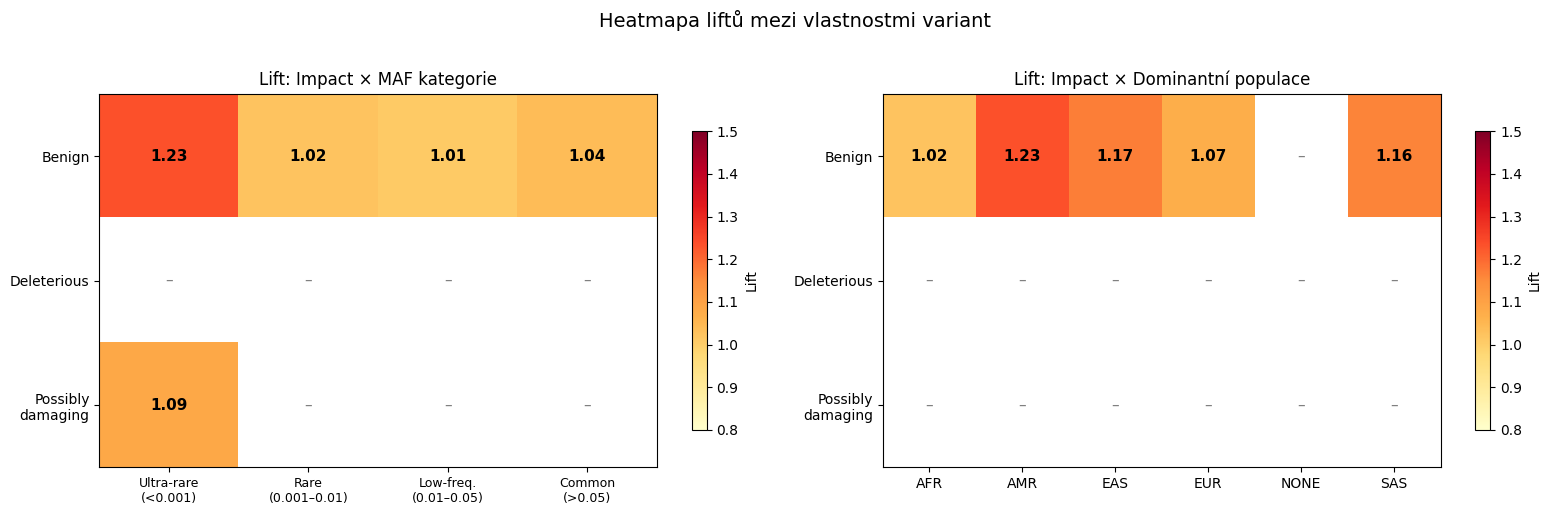

In [242]:
# === Vizualizace 1: Heatmapa liftů mezi páry kategorií ===
import numpy as np

# Vytvoříme matice liftů pro Impact × MAF a Impact × DOMINANT_POP
impact_cats = ['Impact_Benign', 'Impact_Deleterious', 'Impact_Possibly_damaging']
maf_cats = ['MAF_category_Ultra-rare (<0.001)', 'MAF_category_Rare (0.001-0.01)', 
            'MAF_category_Low-frequency (0.01–0.05)', 'MAF_category_Common  (>0.05)']
pop_cats = ['DOMINANT_POP_AFR', 'DOMINANT_POP_AMR', 'DOMINANT_POP_EAS', 
            'DOMINANT_POP_EUR', 'DOMINANT_POP_NONE', 'DOMINANT_POP_SAS']

# Krátké popisky
impact_labels = ['Benign', 'Deleterious', 'Possibly\ndamaging']
maf_labels = ['Ultra-rare\n(<0.001)', 'Rare\n(0.001–0.01)', 'Low-freq.\n(0.01–0.05)', 'Common\n(>0.05)']
pop_labels = ['AFR', 'AMR', 'EAS', 'EUR', 'NONE', 'SAS']

def build_lift_matrix(rules, row_cats, col_cats):
    matrix = np.full((len(row_cats), len(col_cats)), np.nan)
    for _, rule in rules.iterrows():
        items = set(rule['antecedents']) | set(rule['consequents'])
        for i, rc in enumerate(row_cats):
            for j, cc in enumerate(col_cats):
                if rc in items and cc in items:
                    matrix[i, j] = rule['lift']
    return matrix

lift_impact_maf = build_lift_matrix(rules_u2, impact_cats, maf_cats)
lift_impact_pop = build_lift_matrix(rules_u2, impact_cats, pop_cats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Impact × MAF
im1 = ax1.imshow(lift_impact_maf, cmap='YlOrRd', aspect='auto', vmin=0.8, vmax=1.5)
ax1.set_xticks(range(len(maf_labels)))
ax1.set_xticklabels(maf_labels, fontsize=9)
ax1.set_yticks(range(len(impact_labels)))
ax1.set_yticklabels(impact_labels, fontsize=10)
ax1.set_title('Lift: Impact × MAF kategorie', fontsize=12)
for i in range(len(impact_cats)):
    for j in range(len(maf_cats)):
        val = lift_impact_maf[i, j]
        if not np.isnan(val):
            ax1.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')
        else:
            ax1.text(j, i, '–', ha='center', va='center', fontsize=11, color='grey')
plt.colorbar(im1, ax=ax1, label='Lift', shrink=0.8)

# Impact × DOMINANT_POP
im2 = ax2.imshow(lift_impact_pop, cmap='YlOrRd', aspect='auto', vmin=0.8, vmax=1.5)
ax2.set_xticks(range(len(pop_labels)))
ax2.set_xticklabels(pop_labels, fontsize=10)
ax2.set_yticks(range(len(impact_labels)))
ax2.set_yticklabels(impact_labels, fontsize=10)
ax2.set_title('Lift: Impact × Dominantní populace', fontsize=12)
for i in range(len(impact_cats)):
    for j in range(len(pop_cats)):
        val = lift_impact_pop[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')
        else:
            ax2.text(j, i, '–', ha='center', va='center', fontsize=11, color='grey')
plt.colorbar(im2, ax=ax2, label='Lift', shrink=0.8)

plt.suptitle('Heatmapa liftů mezi vlastnostmi variant', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

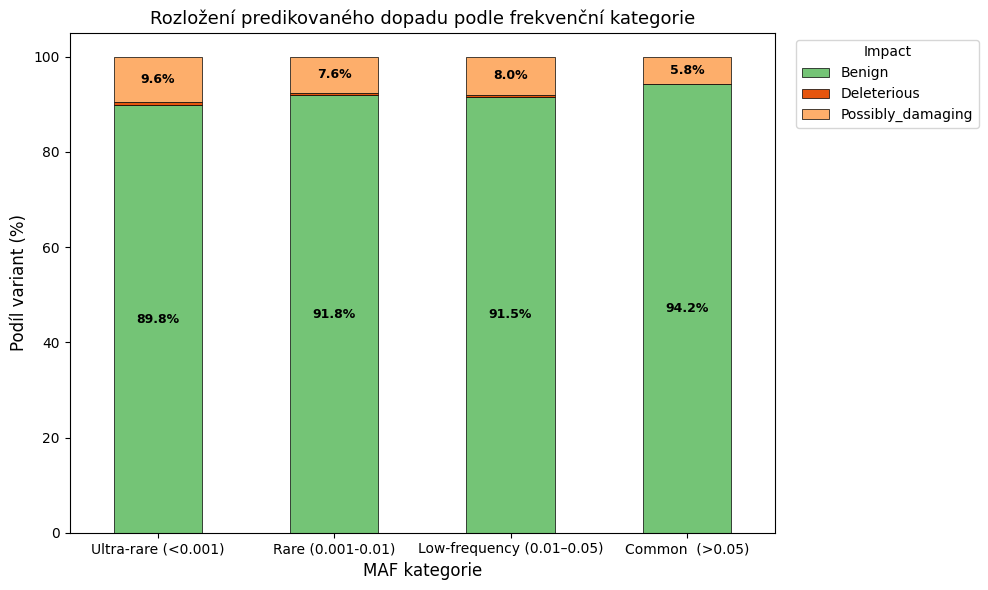

In [243]:
# === Vizualizace 2: Rozložení Impactu podle MAF kategorie ===
# Počítáme z původních dat, ne z pravidel
impact_by_maf = pd.crosstab(
    features_df_clean['Impact'], 
    pd.Categorical(features_df_clean['MAF_category'], 
                   categories=['Ultra-rare (<0.001)', 'Rare (0.001-0.01)', 
                               'Low-frequency (0.01–0.05)', 'Common  (>0.05)'],
                   ordered=True),
    normalize='columns'
) * 100

colors_impact = {'Benign': '#74c476', 'Possibly_damaging': '#fdae6b', 'Deleterious': '#e6550d'}

ax = impact_by_maf.T.plot(kind='bar', stacked=True, figsize=(10, 6),
                           color=[colors_impact[c] for c in impact_by_maf.index],
                           edgecolor='black', linewidth=0.5)
ax.set_ylabel('Podíl variant (%)', fontsize=12)
ax.set_xlabel('MAF kategorie', fontsize=12)
ax.set_title('Rozložení predikovaného dopadu podle frekvenční kategorie', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.legend(title='Impact', fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')

# Přidáme procenta do sloupců
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f'{height:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# === Vizualizace 3: Scatter pravidel — support vs confidence ===
fig, ax = plt.subplots(figsize=(10, 6))

# Rozlišíme pravidla s Impact a bez
has_impact = rules_u2.apply(lambda r:
    any('Impact' in x for x in r['antecedents']) or 
    any('Impact' in x for x in r['consequents']), axis=1)

# Pravidla BEZ Impact
ax.scatter(
    rules_u2.loc[~has_impact, 'support'],
    rules_u2.loc[~has_impact, 'confidence'],
    s=80, c='#bdbdbd', edgecolors='black', linewidth=0.5, alpha=0.7,
    label=f'Bez Impact ({(~has_impact).sum()} pravidel)'
)

# Pravidla S Impact
scatter2 = ax.scatter(
    rules_u2.loc[has_impact, 'support'],
    rules_u2.loc[has_impact, 'confidence'],
    s=80, c=rules_u2.loc[has_impact, 'lift'], cmap='YlOrRd',
    edgecolors='black', linewidth=0.5, alpha=0.8,
    label=f'S Impact ({has_impact.sum()} pravidel)'
)

plt.colorbar(scatter2, label='Lift', shrink=0.8)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Asociační pravidla úlohy 2: Support vs Confidence', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

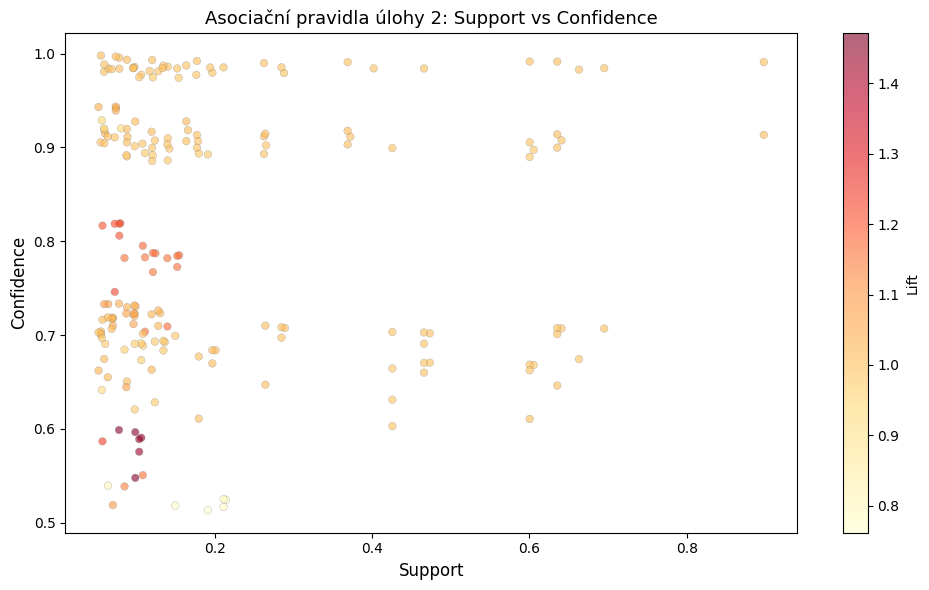

In [33]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules_u2['support'], rules_u2['confidence'], 
                      c=rules_u2['lift'], cmap='YlOrRd', alpha=0.6, s=30, edgecolors='grey', linewidth=0.3)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Asociační pravidla úlohy 2: Support vs Confidence', fontsize=13)
plt.tight_layout()
plt.show()


#### Úloha 3 - Asociační pravidla mezi mutacemi v různých populacích
možnost pravidel typu „mutace A a B se často vyskytují u populace Y, ale ne u Z“.

In [275]:
# Definice meta a mutačních sloupců
meta_cols = [col for col in matrix_lide.columns if col.startswith(('Sex_', 'Pop_', 'SuperPop_'))]
mutation_cols = [col for col in matrix_lide.columns if not col.startswith(('Sex_', 'Pop_', 'SuperPop_'))]

mutation_support = matrix_lide[mutation_cols].mean()
for low, high in [(0.01, 0.5), (0.05, 0.5), (0.1, 0.5)]:
    count = ((mutation_support >= low) & (mutation_support <= high)).sum()
    print(f"Support {low}–{high}: {count} mutací")

Support 0.01–0.5: 1107 mutací
Support 0.05–0.5: 668 mutací
Support 0.1–0.5: 476 mutací


In [276]:
# Mutace se support 0.05–0.5
keep_mutations_mid = mutation_support[(mutation_support >= 0.05) & (mutation_support <= 0.5)].index.tolist()
print(f"Mutací: {len(keep_mutations_mid)}")

matrix_u3 = matrix_lide[meta_cols + keep_mutations_mid]
print(f"Rozměr matice: {matrix_u3.shape}")

Mutací: 668
Rozměr matice: (2504, 702)


In [277]:
%%time
frequent_itemsets_u3 = fpgrowth(matrix_u3, min_support=0.1, use_colnames=True, max_len=3)
print(f"Počet frekventovaných itemsetů: {len(frequent_itemsets_u3)}")

Počet frekventovaných itemsetů: 1052916
CPU times: user 7min 9s, sys: 2.84 s, total: 7min 12s
Wall time: 7min 13s


In [278]:
%%time
rules_u3 = association_rules(frequent_itemsets_u3, metric="confidence", min_threshold=0.8, num_itemsets=len(frequent_itemsets_u3))
print(f"Počet pravidel: {len(rules_u3)}")

Počet pravidel: 1311671
CPU times: user 9.91 s, sys: 478 ms, total: 10.4 s
Wall time: 10.6 s


In [290]:
def is_superpop(item):
    return item.startswith('SuperPop_')

def is_mutation(item):
    return not item.startswith(('Sex_', 'Pop_', 'SuperPop_'))

# Filtrujeme pravidla: na jedné straně mutace, na druhé superpopulace
# Vyloučíme pravidla obsahující Sex_ nebo Pop_ (subpopulace)
rules_u3_filtered = rules_u3[
    rules_u3.apply(lambda r:
        # Žádná strana nesmí obsahovat Sex_ nebo Pop_
        not any(x.startswith(('Sex_', 'Pop_')) for x in r['antecedents']) and
        not any(x.startswith(('Sex_', 'Pop_')) for x in r['consequents']) and
        (
            (any(is_mutation(x) for x in r['antecedents']) and any(is_superpop(x) for x in r['consequents'])) or
            (any(is_superpop(x) for x in r['antecedents']) and any(is_mutation(x) for x in r['consequents']))
        )
    , axis=1)
]

print(f"Pravidla mutace ↔ superpopulace: {len(rules_u3_filtered)}")
rules_u3_filtered.sort_values('lift', ascending=False).head(20)

Pravidla mutace ↔ superpopulace: 16736


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1293751,"frozenset({21_36302887_T_C, SuperPop_AFR})",frozenset({21_36301646_T_A}),0.100240,0.104233,0.100240,1.000000,9.593870,1.0,0.089791,inf,0.995561,0.961686,1.000000,0.980843
1293750,"frozenset({21_36301646_T_A, SuperPop_AFR})",frozenset({21_36302887_T_C}),0.100240,0.104233,0.100240,1.000000,9.593870,1.0,0.089791,inf,0.995561,0.961686,1.000000,0.980843
1293753,frozenset({21_36302887_T_C}),"frozenset({21_36301646_T_A, SuperPop_AFR})",0.104233,0.100240,0.100240,0.961686,9.593870,1.0,0.089791,23.483746,1.000000,0.961686,0.957417,0.980843
1293752,frozenset({21_36301646_T_A}),"frozenset({21_36302887_T_C, SuperPop_AFR})",0.104233,0.100240,0.100240,0.961686,9.593870,1.0,0.089791,23.483746,1.000000,0.961686,0.957417,0.980843
1279553,frozenset({21_36321039_C_T}),"frozenset({SuperPop_AFR, 21_36320823_T_C})",0.117412,0.105831,0.105831,0.901361,8.517007,1.0,0.093405,9.065027,1.000000,0.901361,0.889686,0.950680
1279551,"frozenset({21_36321039_C_T, SuperPop_AFR})",frozenset({21_36320823_T_C}),0.105831,0.117412,0.105831,1.000000,8.517007,1.0,0.093405,inf,0.987048,0.901361,1.000000,0.950680
1279552,"frozenset({SuperPop_AFR, 21_36320823_T_C})",frozenset({21_36321039_C_T}),0.105831,0.117412,0.105831,1.000000,8.517007,1.0,0.093405,inf,0.987048,0.901361,1.000000,0.950680
1279554,frozenset({21_36320823_T_C}),"frozenset({21_36321039_C_T, SuperPop_AFR})",0.117412,0.105831,0.105831,0.901361,8.517007,1.0,0.093405,9.065027,1.000000,0.901361,0.889686,0.950680
1296851,"frozenset({21_36444341_C_T, SuperPop_AFR})",frozenset({21_36442679_C_T}),0.103435,0.118211,0.103435,1.000000,8.459459,1.0,0.091207,inf,0.983519,0.875000,1.000000,0.937500
1296985,"frozenset({21_36445539_C_T, SuperPop_AFR})",frozenset({21_36442679_C_T}),0.100639,0.118211,0.100639,1.000000,8.459459,1.0,0.088742,inf,0.980462,0.851351,1.000000,0.925676


In [292]:
# Pravidla podle populací
for pop in ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']:
    count = rules_u3_filtered[
        rules_u3_filtered.apply(lambda r: f'SuperPop_{pop}' in r['antecedents'] or f'SuperPop_{pop}' in r['consequents'], axis=1)
    ].shape[0]
    print(f"SuperPop_{pop}: {count} pravidel")


SuperPop_AFR: 15044 pravidel
SuperPop_EAS: 870 pravidel
SuperPop_EUR: 638 pravidel
SuperPop_SAS: 184 pravidel
SuperPop_AMR: 0 pravidel


In [293]:
# Top pravidla pro každou populaci
for pop in ['AFR', 'EAS', 'EUR']:
    print(f"\n=== SuperPop_{pop} ===")
    pop_rules = rules_u3_filtered[
        rules_u3_filtered.apply(lambda r: f'SuperPop_{pop}' in r['antecedents'] or f'SuperPop_{pop}' in r['consequents'], axis=1)
    ].sort_values('lift', ascending=False)
    print(pop_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())


=== SuperPop_AFR ===
                                        antecedents                                 consequents   support  confidence      lift
1293750  frozenset({21_36301646_T_A, SuperPop_AFR})                frozenset({21_36302887_T_C})  0.100240    1.000000  9.593870
1293753                frozenset({21_36302887_T_C})  frozenset({21_36301646_T_A, SuperPop_AFR})  0.100240    0.961686  9.593870
1293752                frozenset({21_36301646_T_A})  frozenset({21_36302887_T_C, SuperPop_AFR})  0.100240    0.961686  9.593870
1293751  frozenset({21_36302887_T_C, SuperPop_AFR})                frozenset({21_36301646_T_A})  0.100240    1.000000  9.593870
1279551  frozenset({21_36321039_C_T, SuperPop_AFR})                frozenset({21_36320823_T_C})  0.105831    1.000000  8.517007
1279552  frozenset({SuperPop_AFR, 21_36320823_T_C})                frozenset({21_36321039_C_T})  0.105831    1.000000  8.517007
1279553                frozenset({21_36321039_C_T})  frozenset({SuperPop_AFR, 21_3

In [294]:
# Pravidla s více mutacemi na jedné straně (novinka díky max_len=3)
multi_mut_rules = rules_u3_filtered[
    rules_u3_filtered.apply(lambda r:
        sum(is_mutation(x) for x in r['antecedents']) >= 2 or
        sum(is_mutation(x) for x in r['consequents']) >= 2
    , axis=1)
]
print(f"Pravidla s ≥2 mutacemi na jedné straně: {len(multi_mut_rules)}")

# Rozložení podle populací
for pop in ['AFR', 'EAS', 'EUR']:
    count = multi_mut_rules[
        multi_mut_rules.apply(lambda r: f'SuperPop_{pop}' in r['antecedents'] or f'SuperPop_{pop}' in r['consequents'], axis=1)
    ].shape[0]
    if count > 0:
        print(f"  SuperPop_{pop}: {count} pravidel")

# Top 10 multi-mutačních pravidel
print(f"\nTop 10 multi-mutačních pravidel (podle liftu):")
top_multi = multi_mut_rules.sort_values('lift', ascending=False).head(10)
for _, row in top_multi.iterrows():
    ant = ', '.join(row['antecedents'])
    con = ', '.join(row['consequents'])
    print(f"  {ant} → {con}")
    print(f"    Support={row['support']:.4f}  Conf={row['confidence']:.4f}  Lift={row['lift']:.4f}")
    print()

Pravidla s ≥2 mutacemi na jedné straně: 4932
  SuperPop_AFR: 4932 pravidel

Top 10 multi-mutačních pravidel (podle liftu):
  21_36244143_CTT_C, 21_36489489_C_T → SuperPop_AFR
    Support=0.1070  Conf=0.9817  Lift=3.7188

  21_36360000_T_C, 21_36410843_C_T → SuperPop_AFR
    Support=0.1138  Conf=0.9794  Lift=3.7101

  21_36366814_C_T, 21_36254807_T_C → SuperPop_AFR
    Support=0.1102  Conf=0.9787  Lift=3.7076

  21_36489489_C_T, 21_36302917_C_T → SuperPop_AFR
    Support=0.1078  Conf=0.9783  Lift=3.7058

  21_36301095_A_G, 21_36489489_C_T → SuperPop_AFR
    Support=0.1070  Conf=0.9781  Lift=3.7052

  21_36366814_C_T, 21_36410367_C_A-T → SuperPop_AFR
    Support=0.1230  Conf=0.9778  Lift=3.7040

  21_36366220_T_C, 21_36333654_AAAT_AAATAAT-A → SuperPop_AFR
    Support=0.1030  Conf=0.9773  Lift=3.7021

  21_36489489_C_T, 21_36304178_C_T → SuperPop_AFR
    Support=0.1030  Conf=0.9773  Lift=3.7021

  21_36366814_C_T, 21_36333654_AAAT_AAATAAT-A → SuperPop_AFR
    Support=0.1030  Conf=0.9773  

In [295]:
rules_u3.sort_values('lift', ascending=False).to_csv('rules_u3_all.csv', index=False)
print(f"Uloženo {len(rules_u3)} pravidel do rules_u3_all.csv")


Uloženo 1311671 pravidel do rules_u3_all.csv


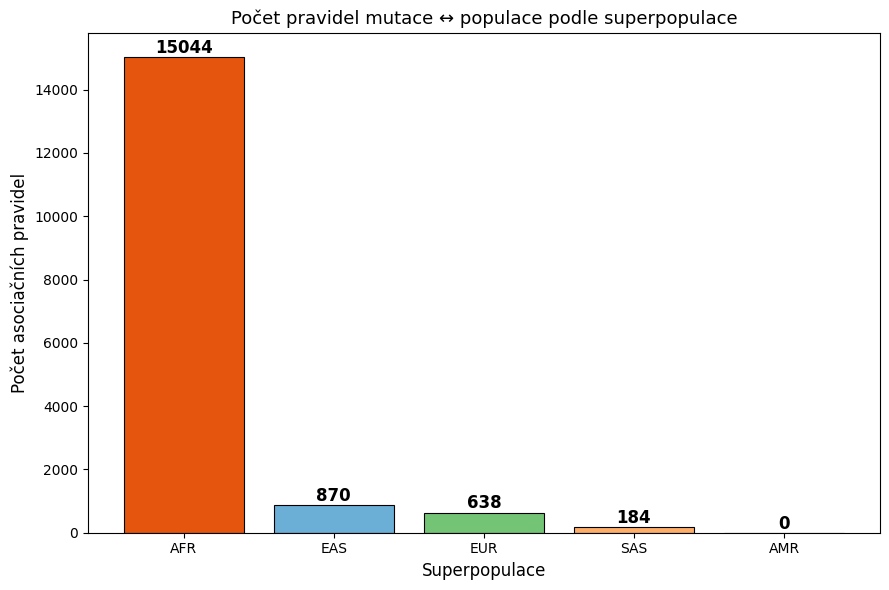

In [296]:
# === Vizualizace 1: Počet pravidel podle superpopulace ===
pop_names = ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']
pop_rule_counts = []
for pop in pop_names:
    count = rules_u3_filtered[
        rules_u3_filtered.apply(lambda r: f'SuperPop_{pop}' in r['antecedents'] or f'SuperPop_{pop}' in r['consequents'], axis=1)
    ].shape[0]
    pop_rule_counts.append(count)

colors_pop = ['#e6550d', '#6baed6', '#74c476', '#fdae6b', '#9e9ac8']

plt.figure(figsize=(9, 6))
bars = plt.bar(pop_names, pop_rule_counts, color=colors_pop, edgecolor='black', linewidth=0.8)

# Přidáme hodnoty nad sloupce
for bar, count in zip(bars, pop_rule_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Superpopulace', fontsize=12)
plt.ylabel('Počet asociačních pravidel', fontsize=12)
plt.title('Počet pravidel mutace ↔ populace podle superpopulace', fontsize=13)
plt.tight_layout()
plt.show()

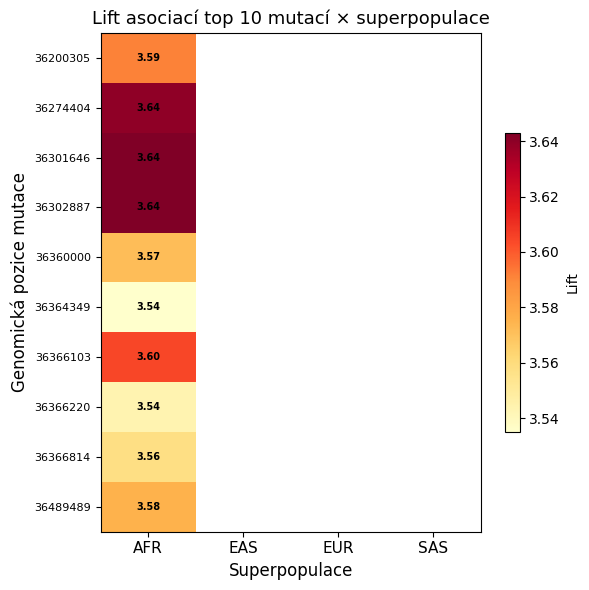

In [302]:
# === Vizualizace 2: Heatmapa mutace × superpopulace (top mutace podle liftu) ===
import numpy as np

pop_names_heat = ['AFR', 'EAS', 'EUR', 'SAS']

# Vybereme jen pravidla 1:1 (jedna mutace ↔ jedna superpopulace)
rules_u3_single = rules_u3_filtered[
    (rules_u3_filtered['antecedents'].apply(len) == 1) &
    (rules_u3_filtered['consequents'].apply(len) == 1)
].copy()

# Extrahujeme mutaci a populaci z každého pravidla
def extract_mut_pop(row):
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    if ant.startswith('SuperPop_'):
        return con, ant.replace('SuperPop_', '')
    else:
        return ant, con.replace('SuperPop_', '')

rules_u3_single[['mutation', 'population']] = rules_u3_single.apply(
    lambda r: pd.Series(extract_mut_pop(r)), axis=1)

# Top 30 mutací podle maximálního liftu
top_mutations = (rules_u3_single.groupby('mutation')['lift'].max()
                 .sort_values(ascending=False).head(10).index.tolist())

# Seřadíme podle genomické pozice
top_mutations_sorted = sorted(top_mutations, key=lambda x: int(x.split('_')[1]))

# Sestavíme matici liftů
lift_matrix = np.full((len(top_mutations_sorted), len(pop_names_heat)), np.nan)
for _, row in rules_u3_single.iterrows():
    if row['mutation'] in top_mutations_sorted and row['population'] in pop_names_heat:
        i = top_mutations_sorted.index(row['mutation'])
        j = pop_names_heat.index(row['population'])
        lift_matrix[i, j] = max(lift_matrix[i, j] if not np.isnan(lift_matrix[i, j]) else 0, row['lift'])

# Popisky — jen pozice
mut_labels = [m.split('_')[1] for m in top_mutations_sorted]

fig, ax = plt.subplots(figsize=(6, 6))
masked = np.ma.masked_where(np.isnan(lift_matrix), lift_matrix)
im = ax.imshow(masked, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(pop_names_heat)))
ax.set_xticklabels(pop_names_heat, fontsize=11)
ax.set_yticks(range(len(mut_labels)))
ax.set_yticklabels(mut_labels, fontsize=8)

# Hodnoty do buněk
for i in range(len(top_mutations_sorted)):
    for j in range(len(pop_names_heat)):
        val = lift_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, fontweight='bold')

plt.colorbar(im, label='Lift', shrink=0.6)
ax.set_xlabel('Superpopulace', fontsize=12)
ax.set_ylabel('Genomická pozice mutace', fontsize=12)
ax.set_title('Lift asociací top 10 mutací × superpopulace', fontsize=13)
plt.tight_layout()
plt.show()

In [298]:
# Vybereme nejlepší pravidlo pro každou populaci
summary_rows = []
for pop in ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']:
    pop_rules = rules_u3_filtered[
        rules_u3_filtered.apply(lambda r: f'SuperPop_{pop}' in r['antecedents'] or f'SuperPop_{pop}' in r['consequents'], axis=1)
    ].sort_values('lift', ascending=False)
    if len(pop_rules) > 0:
        best = pop_rules.iloc[0]
        summary_rows.append({
            'Populace': pop,
            'Počet pravidel': len(pop_rules),
            'Pravidlo': f"{set(best['antecedents'])} → {set(best['consequents'])}",
            'Support': round(best['support'], 4),
            'Confidence': round(best['confidence'], 4),
            'Lift': round(best['lift'], 4)
        })
    else:
        summary_rows.append({
            'Populace': pop,
            'Počet pravidel': 0,
            'Pravidlo': '—',
            'Support': None,
            'Confidence': None,
            'Lift': None
        })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Populace,Počet pravidel,Pravidlo,Support,Confidence,Lift
0,AFR,15044,"{'21_36301646_T_A', 'SuperPop_AFR'} → {'21_363...",0.1002,1.0000,9.5939
1,EAS,870,"{'SuperPop_EAS', '21_36452256_T_C'} → {'21_364...",0.1182,0.9966,3.3010
2,EUR,638,"{'SuperPop_EUR', '21_36233905_C_G'} → {'21_362...",0.1014,0.9961,4.0424
3,SAS,184,"{'SuperPop_SAS', '21_36487426_A_G'} → {'21_364...",0.1014,1.0000,2.4240
4,AMR,0,—,NaN,NaN,NaN
